EDA Workflow:

1. EDA Objectives & Scope
2. Dataset Overview (post-cleaning)
3. Univariate Analysis
   ├── Numerical variables
   ├── Categorical variables
4. Bivariate Analysis
   ├── Numerical vs Numerical
   ├── Categorical vs Numerical
   ├── Categorical vs Categorical
5. Customer Behavior Patterns
6. Key Observations & Hypotheses

---

# **EDA Objectives & Scope** 

---

The objective of this exploratory analysis is to identify behavioral patterns, spending trends, and customer engagement signals within the cleaned consumer shopping dataset.

The analysis focuses on understanding how demographic attributes, product characteristics, promotional mechanisms, and purchase frequency influence transaction behavior and customer loyalty.

This phase is exploratory in nature. No feature engineering, encoding, or predictive modeling is performed at this stage.



In [79]:
#Dependencies
#Terminal : pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Matplotlib is used for exploratory visualizations in this notebook due to its stability, minimal dependency requirements, and consistent rendering across environments. As the primary objective of EDA is analytical understanding rather than presentation, static and reproducible plots are preferred over interactive or stylistic visualizations.


---

# **Dataset Overview (Post-Cleaning)** 

---

Exploratory analysis is performed on the cleaned dataset to ensure that observed behavioral patterns reflect genuine customer activity rather than data quality artifacts.

Each record represents an individual customer purchase event enriched with demographic, product, promotional, and behavioral attributes.


In [3]:
df = pd.read_csv('../data/processed/consumer_data_cleaned.csv')
print("Data Size: ", df.shape)
df.head(10)

Data Size:  (3900, 19)


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,purchase_outlier_flag
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,True,True,14,Venmo,Fortnightly,False
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,True,True,2,Cash,Fortnightly,False
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,True,True,23,Credit Card,Weekly,False
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,True,True,49,Paypal,Weekly,False
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,True,True,31,Paypal,Annually,False
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,True,True,14,Venmo,Weekly,False
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,True,True,49,Cash,Quarterly,False
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,True,True,19,Credit Card,Weekly,False
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,True,True,8,Venmo,Annually,False
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,True,True,4,Cash,Quarterly,False


---

# **Univariate Analysis** 

---

Understand each variable independently.

In [4]:
df.dtypes

customer_id                 int64
age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount             int64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
subscription_status        object
shipping_type              object
discount_applied             bool
promo_code_used              bool
previous_purchases          int64
payment_method             object
frequency_of_purchases     object
purchase_outlier_flag        bool
dtype: object

---
### **1. Numerical Variables**
---
Goal: Understand each numerical variable independently in terms of:

- distribution
- central tendency
- spread
- skewness
- business relevance

In [5]:
numerical_cols = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases"
]

### **1.1 Descriptive Statistics for Numerical Features**

In [6]:
df[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,3900.0,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
purchase_amount,3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
review_rating,3900.0,3.750051,0.713590,2.5,3.1,3.8,4.4,5.0
previous_purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0


Summary statistics were evaluated to understand the distribution, central tendency, and variability of numerical attributes related to customer demographics, spending behavior, engagement intensity, and satisfaction.

### **1.2 Distribution Analysis (Histograms) for Numerical Features**

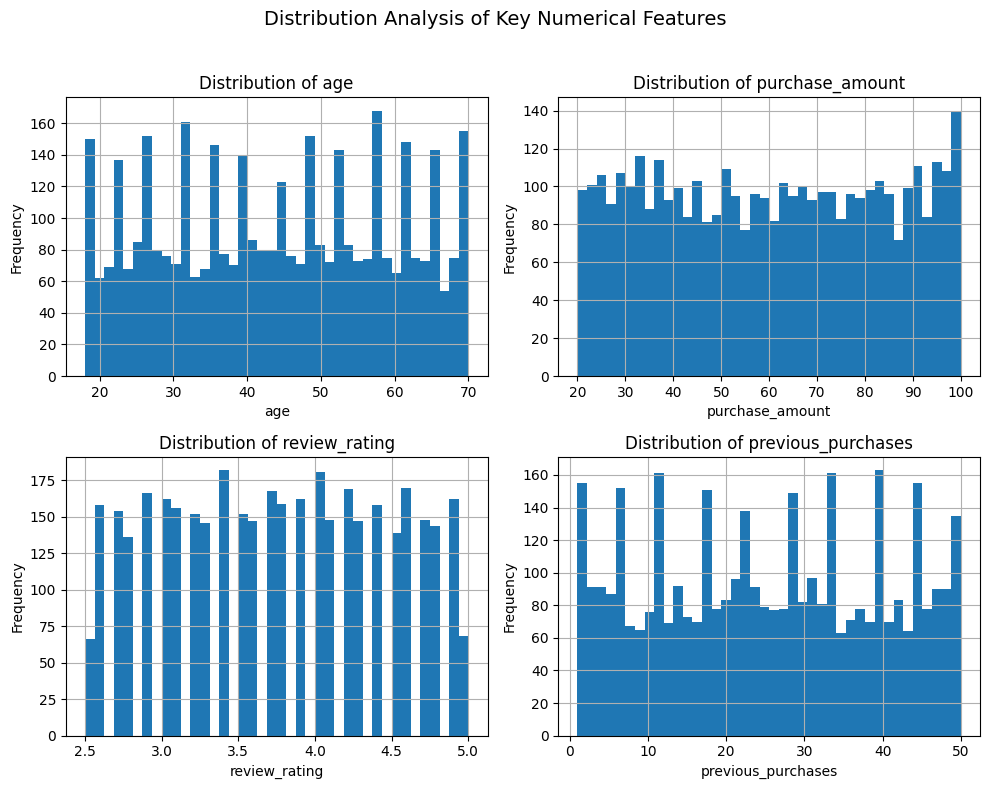

In [40]:
plt.figure(figsize=(10,8))
i=1

for col in numerical_cols:
    plt.subplot(2, 2, i)
    df[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    i+=1

plt.suptitle("Distribution Analysis of Key Numerical Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Review Criteria:**

- Age:
Younger vs older dominance
|| Even vs skewed distribution
- Purchase Amount:
Right skew → premium customers
|| Tight band → pricing control
- Review Rating:
Clustered near 4–5 → satisfaction bias
|| Wide spread → mixed experience
- Previous Purchases:
Many low values → transactional base
|| Long tail → loyal customers


### **Key Observations**

Distribution plots were analyzed to understand data spread, concentration patterns, and customer behavior tendencies across numerical features.

- **Age:**  
The age distribution appears fairly uniform across the range, indicating a well-balanced customer base without strong dominance from a specific age group. This suggests that purchasing behavior is not limited to a narrow demographic segment.

- **Purchase Amount:**  
Purchase amounts are evenly distributed with no extreme right-skew, indicating consistent spending behavior across customers. This implies limited dependency on a small group of high-value customers and reflects stable revenue contribution.

- **Review Rating:**  
Review ratings are concentrated between 3 and 5, with higher density around upper values, suggesting generally positive customer feedback and overall satisfaction with the product or service.

- **Previous Purchases:**  
The distribution of previous purchases shows moderate spread, indicating the presence of both new and repeat customers. This reflects a healthy mix of transactional and returning users, supporting sustainable engagement patterns.

Overall, the distributions exhibit minimal skewness and balanced spread, confirming strong data quality and enabling reliable aggregation, KPI analysis, and downstream modeling.


### **1.3 Spread & Outlier Awareness (Boxplots) for Numerical Features**

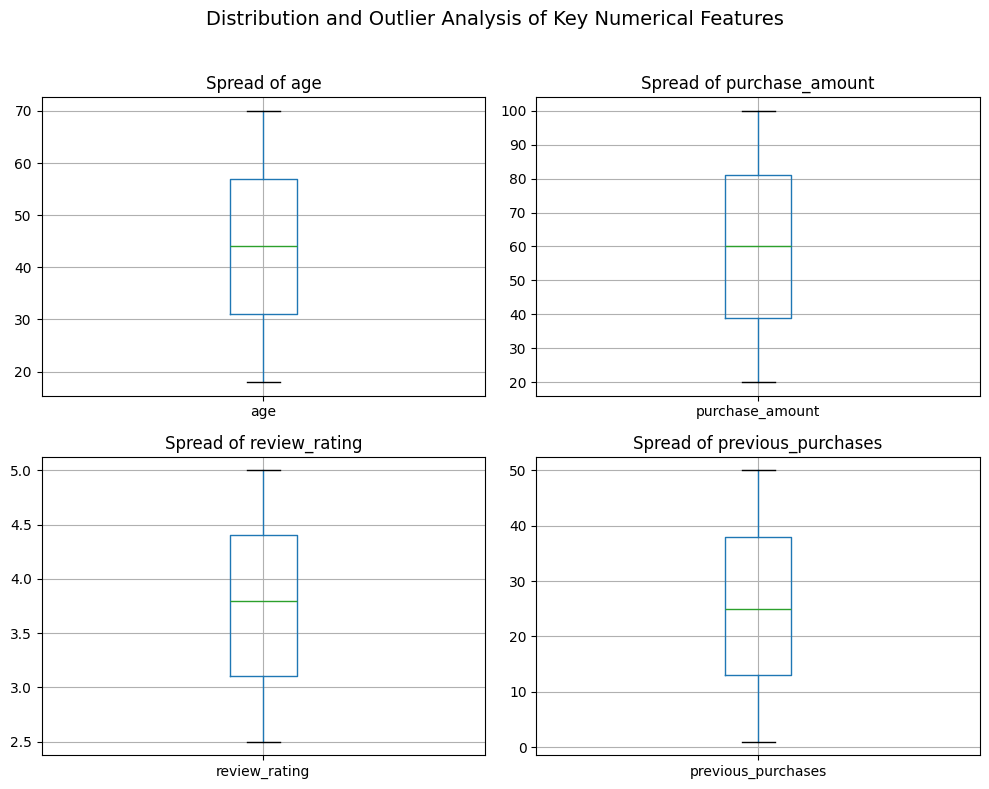

In [39]:
plt.figure(figsize=(10,8))
i=1

for col in numerical_cols:
    plt.subplot(2, 2, i)
    df.boxplot(column=col)
    plt.title(f"Spread of {col}")
    i+=1

plt.suptitle("Distribution and Outlier Analysis of Key Numerical Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Box plots were used to examine the distribution, variability, and presence of outliers across key numerical variables.
Observed outliers were retained for further analysis, as they may represent genuine high-value or highly engaged customers, which are critical for business analysis and custoemr segmentation.


Key observations:
- Age shows moderate spread, indicating a diverse customer base.
- Purchase amount exhibits wider variability, suggesting differences in customer spending behavior.
- Review ratings are relatively concentrated, indicating consistent customer feedback.
- Previous purchases display noticeable spread, highlighting varying engagement levels.


### **1.4 Skewness Check**

In [9]:
df[numerical_cols].skew()

age                  -0.006380
purchase_amount       0.012702
review_rating         0.001418
previous_purchases    0.003121
dtype: float64

Skewness metrics were reviewed to understand distribution asymmetry and inform potential transformation considerations in later stages.

- Skew > 1 → heavy right tail
- Mean > Median → skewed distribution

All variables exhibit skewness values close to zero, indicating approximately symmetric distributions. This suggests that the mean and median are closely aligned, making average-based metrics statistically reliable.


---
### **2. Categorical Variables**
---
Goal: To understand the distribution of customer transactions across categorical attributes including demographics, product characteristics, promotional usage, logistics preferences, and purchasing behavior frequency.

This analysis helps identify dominant customer segments, preference concentration, and category-level imbalance.

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'purchase_outlier_flag'],
      dtype='object')

In [11]:
df.dtypes

customer_id                 int64
age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount             int64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
subscription_status        object
shipping_type              object
discount_applied             bool
promo_code_used              bool
previous_purchases          int64
payment_method             object
frequency_of_purchases     object
purchase_outlier_flag        bool
dtype: object

In [12]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['gender',
 'item_purchased',
 'category',
 'location',
 'size',
 'color',
 'season',
 'subscription_status',
 'shipping_type',
 'payment_method',
 'frequency_of_purchases']

### **2.1 Frequency Distribution Analysis**

In [14]:
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"Distribution for: {col}")
    print(f"{'='*60}")
    
    display(df[col].value_counts())



Distribution for: gender


gender
Male      2652
Female    1248
Name: count, dtype: int64


Distribution for: item_purchased


item_purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Scarf         157
Shorts        157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-Shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64


Distribution for: category


...

shipping_type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64


Distribution for: payment_method


payment_method
Paypal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


Distribution for: frequency_of_purchases


frequency_of_purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

Criteria for understanding:
- High concentration → dominant behavior
- Long tail → diverse preferences
- Very small counts → potential noise

Insights:
- Gender: Customer base is male-dominant, indicating current demand skew and a clear opportunity for targeted female segment expansion.
- Item Purchased: Purchases are evenly distributed across items, suggesting diversified preferences and limited dependence on any single product.
- Category: Clothing is the primary demand driver, followed by Accessories, while Footwear and Outerwear represent secondary contribution segments.
- Location: Demand is geographically well diversified with no significant regional concentration, reducing location-specific risk.
- Size: Medium and Large sizes account for the majority of purchases, providing clear guidance for inventory prioritization.
- Color: Color preferences are widely dispersed, indicating heterogeneous aesthetic choices and the need for broad assortment coverage.
- Season: Purchases remain stable across seasons, reflecting consistent year-round demand with minimal seasonality risk.
- Subscription Status: Non-subscribers form the majority, highlighting strong potential for subscription-led retention and lifetime value growth.
- Shipping Type: Shipping preferences are evenly split, enabling operational flexibility in fulfillment optimization.
- Payment Method: Payment usage is diversified across methods, emphasizing the importance of maintaining multiple checkout options.
- Purchase Frequency: Customer purchase behavior spans evenly across frequency bands, indicating a mixed base of occasional and repeat buyers.



The categorical distribution reflects a balanced and diversified customer behavior, with key concentration observed in gender and product category, while remaining attributes show broad variability — supporting opportunities in segment-led marketing, subscription conversion, and inventory optimization.


### **2.2 Percentage Contribution Analysis**

In [15]:
for col in categorical_cols:
    print(f"\nPercentage distribution for {col}")
    
    display(
        (df[col].value_counts(normalize=True) * 100)
        .round(2)
        .head(10)
    )



Percentage distribution for gender


gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64


Percentage distribution for item_purchased


item_purchased
Blouse        4.38
Pants         4.38
Jewelry       4.38
Shirt         4.33
Dress         4.26
Sweater       4.21
Jacket        4.18
Coat          4.13
Sunglasses    4.13
Belt          4.13
Name: proportion, dtype: float64


Percentage distribution for category


...

shipping_type
Free Shipping     17.31
Standard          16.77
Store Pickup      16.67
Next Day Air      16.62
Express           16.56
2-Day Shipping    16.08
Name: proportion, dtype: float64


Percentage distribution for payment_method


payment_method
Paypal           17.36
Credit Card      17.21
Cash             17.18
Debit Card       16.31
Venmo            16.26
Bank Transfer    15.69
Name: proportion, dtype: float64


Percentage distribution for frequency_of_purchases


frequency_of_purchases
Every 3 Months    14.97
Annually          14.67
Quarterly         14.44
Monthly           14.18
Bi-Weekly         14.03
Fortnightly       13.90
Weekly            13.82
Name: proportion, dtype: float64

Insights:

- Gender:
The customer base is significantly male-skewed, with males contributing 68% of total customers, indicating a clear dominance of male purchasing behavior and an underpenetrated female segment.

- Item Purchased:
Item-level distribution is highly uniform, with each product contributing approximately 4–4.5% of total purchases. This reflects diversified demand with no single item acting as a volume driver.

- Category:
Clothing accounts for nearly 45% of total purchases, establishing it as the core category. Accessories form a strong secondary segment, while Footwear and Outerwear contribute comparatively lower shares.

- Location:
Geographic distribution is evenly spread, with individual locations contributing roughly 2–2.5% each. This indicates nationally diversified demand with no regional dependency risk.

- Size:
Medium (45%) and Large (27%) sizes dominate demand, together representing over 70% of purchases, providing clear guidance for inventory and supply planning.

- Color:
Color preferences are widely dispersed, with no color exceeding 5% share. This suggests heterogeneous aesthetic preferences and minimal color concentration risk.

- Season:
Purchases are evenly distributed across seasons (~24–26% each), indicating stable year-round demand and limited seasonality impact.

- Subscription Status:
A large majority of customers (73%) are non-subscribers, highlighting substantial opportunity for subscription-driven retention and lifetime value improvement.

- Shipping Type:
Shipping method usage is well balanced across options, with each mode contributing roughly 16–17%, indicating customer flexibility in fulfillment preferences.

- Payment Method:
Payment behavior is evenly diversified across methods, reducing reliance on any single payment channel and supporting smooth transaction flow.

- Purchase Frequency:
Purchase frequency distribution is uniform, with no dominant interval, reflecting a mixed customer base of occasional and repeat buyers.


The percentage distribution reveals high behavioral diversification across most categorical attributes, with meaningful concentration observed primarily in gender, size, category, and subscription status. This structure supports stable operations while presenting clear growth opportunities in female customer acquisition, subscription conversion, and targeted personalization strategies.

### **2.3 Visualization — Bar Charts**

In [27]:
len(categorical_cols)

11

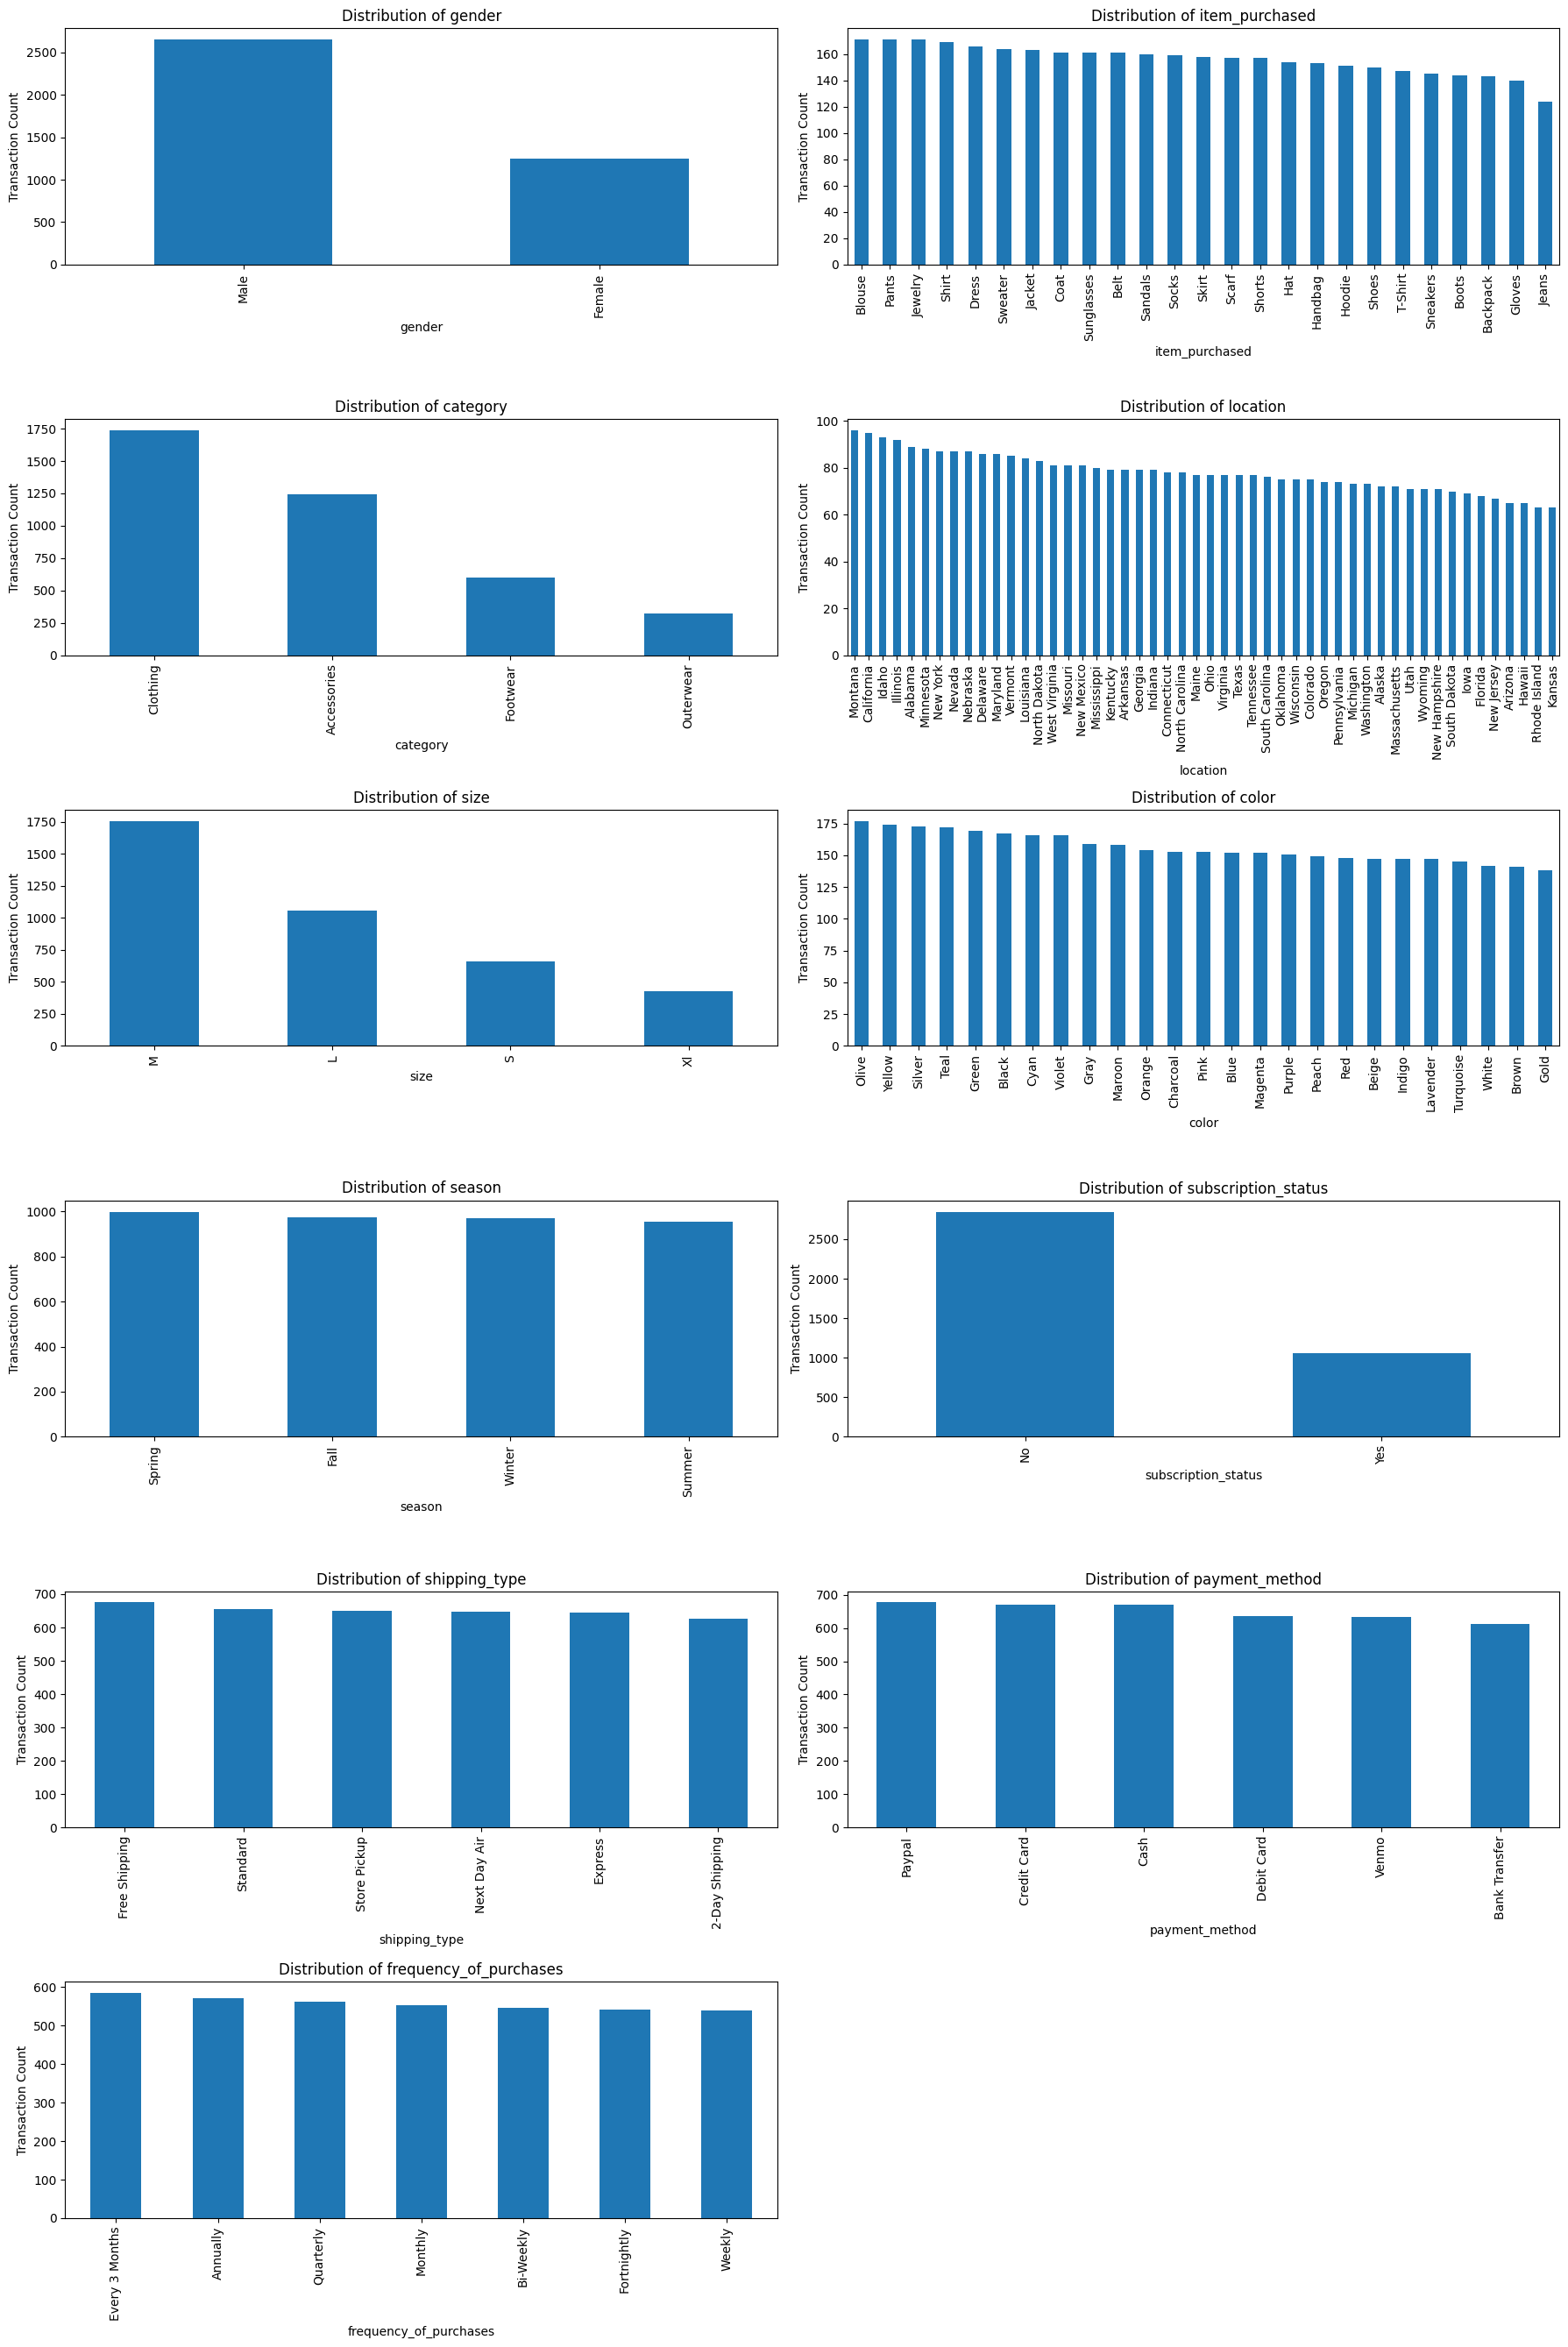

In [38]:
plt.figure(figsize=(18, 28))
i = 1
for col in categorical_cols:
    plt.subplot(6,2, i)
    df[col].value_counts().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=90)
    i=i+1

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Insights:

- Gender: The customer base is predominantly male, indicating a strong gender skew in purchasing behavior. This suggests current offerings and engagement strategies are more aligned with male customers, while the female segment represents a clear growth opportunity.

- Item Purchased: Demand is evenly spread across individual items, with no single product acting as a dominant driver. This reflects diversified product preferences and reduces dependence on any specific SKU, though it also indicates the absence of clear hero products.

- Category: Clothing contributes the largest share of transactions, establishing it as the core business category. Accessories form a strong secondary segment, while Footwear and Outerwear play more specialized, lower-volume roles.

- Location: Purchases are broadly distributed across locations with relatively minor variation. This indicates geographically diversified demand and minimal exposure to region-specific concentration risk.

- Size: Medium and Large sizes account for the majority of purchases, highlighting clear inventory prioritization requirements. Smaller and extra-large sizes show comparatively lower demand and can be managed as tail inventory.

- Color: Color preferences are widely dispersed, with no dominant shade. This suggests heterogeneous aesthetic tastes and supports maintaining a broad color assortment rather than concentrating on limited color palettes.

- Season: Transactions are nearly evenly distributed across all seasons, indicating stable year-round demand and limited seasonality impact on purchasing behavior.

- Subscription Status: Non-subscribed customers form a substantial majority, signaling significant potential for subscription-based retention strategies to enhance customer lifetime value.

- Shipping Type: All shipping options show similar usage levels, implying customer flexibility in fulfillment preferences and allowing operational optimization without materially impacting demand.

- Payment Method: Payment usage is well diversified across methods, reducing reliance on any single channel and reinforcing the importance of offering multiple payment options to minimize checkout friction.

- Frequency of Purchases: Purchase frequency is evenly distributed across time intervals, reflecting a mixed customer base of both occasional and repeat buyers rather than dominance of any single behavior pattern.

The categorical distributions indicate a well-diversified and structurally balanced customer base, with meaningful concentration primarily in gender, category, and size dimensions. The data highlights clear opportunities in female customer expansion, subscription conversion, and targeted personalization, while operational risks related to geography, seasonality, and payment dependency remain low.

### **2.4 Cadinality Assessment**

In [41]:
cardinality_df = (
    df[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
)

cardinality_df


location                  50
color                     25
item_purchased            25
frequency_of_purchases     7
shipping_type              6
payment_method             6
category                   4
season                     4
size                       4
gender                     2
subscription_status        2
dtype: int64

Criteria;
- High-cardinality categorical features:
    - Increase noise
    - Complicate modeling
    - Require grouping later

Insights:

- The dataset shows a mixed cardinality structure across categorical features.

- High-cardinality variables such as location (50) and color / item_purchased (25 each) may introduce noise and dimensional expansion if directly encoded, requiring grouping or alternative encoding strategies.

- Medium-cardinality features (frequency_of_purchases, shipping_type, payment_method) remain manageable and retain useful behavioral detail.

- Low-cardinality variables (category, season, size, gender, subscription_status) are stable and suitable for direct encoding.

Most categorical features are model-friendly, while a limited number of high-cardinality variables will require preprocessing to ensure modeling efficiency and interpretability.

---

# **Bivariate Analysis** 

---

To examine relationships between pairs of variables in order to identify drivers of spending behavior, engagement intensity, and customer preference patterns.

Bivariate analysis helps answer:

- What influences purchase value?
- Which customer segments behave differently?
- How do promotions and subscriptions affect engagement?

---
### **1. Numerical vs Numerical**
---

Variables Used: 
- age
- purchase_amount
- previous_purchases
- review_rating

Understanding whether:

- Older customers spend more
- Loyal customers generate higher value
- Satisfaction relates to spending

### **1.1 Correlation Matrix**

In [44]:
df.select_dtypes(include=['int64', 'float64']).columns.tolist()

['customer_id',
 'age',
 'purchase_amount',
 'review_rating',
 'previous_purchases']

In [45]:
numerical_cols = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases"
]

df[numerical_cols].corr()


,age,purchase_amount,review_rating,previous_purchases
age,1.000000,-0.010424,-0.024463,0.040445
purchase_amount,-0.010424,1.000000,0.029659,0.008063
review_rating,-0.024463,0.029659,1.000000,0.003555
previous_purchases,0.040445,0.008063,0.003555,1.000000


Criteria:

- Correlation	near 0  : weak relationship
- Correlation > 0.3   : moderate positive
- Correlation < -0.3  : moderate negative

Insights:

The correlation matrix shows very weak linear relationships among all numerical variables.

The absence of strong correlations indicates low multicollinearity, making these variables suitable for modeling. However, it also suggests that customer behavior is likely influenced by non-linear patterns or categorical interactions, rather than direct linear relationships among numerical features.All numerical variables exhibit near-zero correlation, indicating very weak linear relationships across features.

This suggests that:

- Purchase amount is not directly driven by age, review rating, or prior purchase history.
- Customer behavior is unlikely to follow simple linear patterns.
- Multicollinearity risk is minimal, making all numerical features safe to retain for modeling.

Customer spending and engagement appear to be influenced more by categorical factors and interaction effects rather than direct numerical relationships.

### **1.2 Scatter Plots**

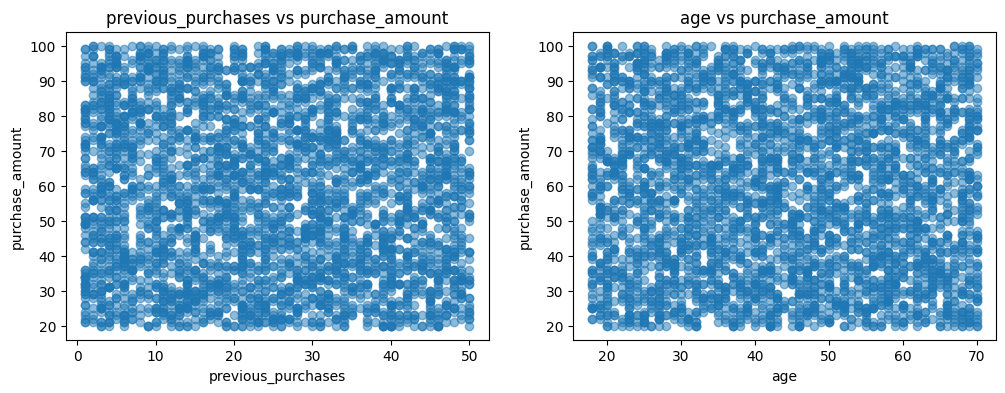

In [53]:
pairs = [
    ("previous_purchases", "purchase_amount"),
    ("age", "purchase_amount")
]

plt.figure(figsize=(12,4))
i=1

for x, y in pairs:
    plt.subplot(1,2, i)
    plt.scatter(df[x], df[y], alpha=0.5)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    i+=1
plt.show()


The scatter plots show a random and widely dispersed pattern with no visible upward or downward trend.

- Previous purchases vs purchase amount indicates that higher customer loyalty does not consistently translate into higher transaction value.

- Age vs purchase amount shows uniform spending behavior across age groups, with no age-driven spending pattern.

---
### **2. Categorical vs Numerical**
---

Business Questions Answered

- Which categories drive higher spend?
- Does discounting increase transaction value?
- Do subscribers behave differently?
- Does season influence spending?

### **2.1 Grouped Statistics**

In [54]:
df.groupby("category")["purchase_amount"].mean().sort_values(ascending=False)

category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: purchase_amount, dtype: float64

In [55]:
df.groupby("season")["purchase_amount"].mean()


season
Fall      61.556923
Spring    58.737738
Summer    58.405236
Winter    60.357364
Name: purchase_amount, dtype: float64

In [57]:
df.groupby("discount_applied")["purchase_amount"].mean()

discount_applied
False    60.130454
True     59.279070
Name: purchase_amount, dtype: float64

In [58]:
df.groupby("subscription_status")["previous_purchases"].mean()


subscription_status
No     25.080436
Yes    26.084520
Name: previous_purchases, dtype: float64

Average transaction values and engagement metrics were compared across customer segments, product categories, promotional conditions, and seasonal dimensions to identify behavioral drivers.

Insights:

- Average purchase amount is similar across product categories, with only minor differences.
- Seasonal impact on spending is low, indicating stable customer behavior throughout the year.
- Discounted purchases show slightly lower average spend, suggesting discounts help conversion more than increasing order value.
- Subscribed customers have higher previous purchases, indicating stronger repeat engagement.


### **2.2 Visualization**

<Figure size 500x300 with 0 Axes>

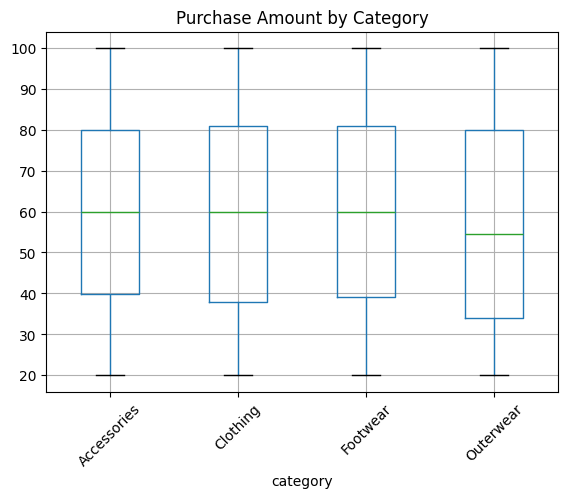

In [69]:
plt.figure(figsize=(5,3))
df.boxplot(column="purchase_amount", by="category")
plt.title("Purchase Amount by Category")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()


<Figure size 500x300 with 0 Axes>

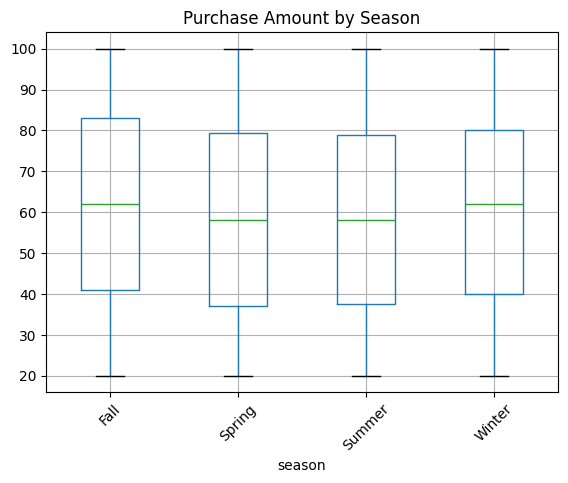

In [71]:
plt.figure(figsize=(5,3))
df.boxplot(column="purchase_amount", by="season")
plt.title("Purchase Amount by Season")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

<Figure size 500x300 with 0 Axes>

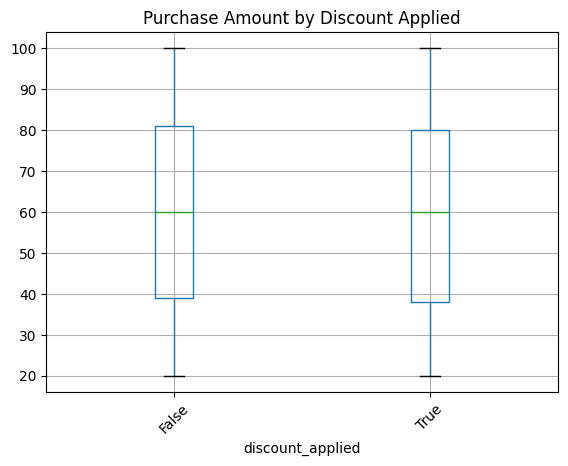

In [72]:
plt.figure(figsize=(5,3))
df.boxplot(column="purchase_amount", by="discount_applied")
plt.title("Purchase Amount by Discount Applied")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

<Figure size 500x300 with 0 Axes>

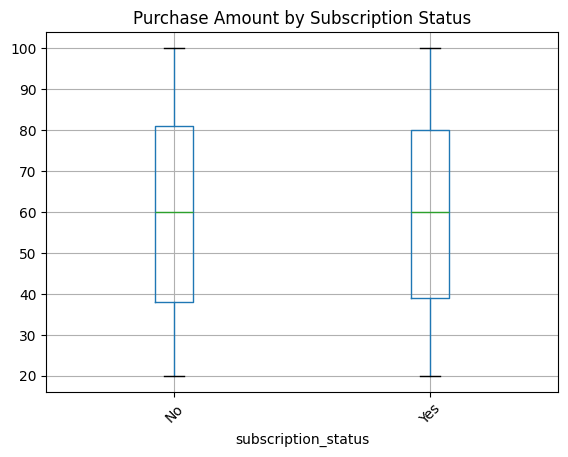

In [73]:
plt.figure(figsize=(5,3))
df.boxplot(column="purchase_amount", by="subscription_status")
plt.title("Purchase Amount by Subscription Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Boxplots were used to compare spending distribution across categorical segments, highlighting variability and median differences in transaction behavior.

---
### **3. Categorical vs Categorical**
---

Understand behavioral combinations, such as:

- Which categories sell in which seasons
- Whether subscribers use discounts differently
- How payment methods vary by purchase frequency

### **3.1 Cross-Tabulation**

In [74]:
pd.crosstab(df["category"], df["season"], normalize="index")

season,Fall,Spring,Summer,Winter
category,,,,
Accessories,0.261290,0.242742,0.251613,0.244355
Clothing,0.245826,0.261370,0.234888,0.257916
Footwear,0.227045,0.272120,0.267112,0.233723
Outerwear,0.271605,0.250000,0.231481,0.246914


In [75]:
pd.crosstab(df["discount_applied"], df["subscription_status"], normalize="index")

subscription_status,No,Yes
discount_applied,,
False,1.000000,0.000000
True,0.372093,0.627907


High % concentration → strong behavioral linkage
Balanced rows → diversified behavior

Cross-tabulation analysis was conducted to evaluate interactions between categorical attributes and identify behavioral combinations influencing purchasing patterns.

Insights:

- Category × Season: 
Purchase distribution across seasons remains largely balanced within each product category. No category shows strong seasonal dependence, indicating consistent demand throughout the year.

- Discount Applied × Subscription Status: 
When no discount is applied, all transactions come from non-subscribed customers.
When discounts are applied, a majority of transactions (≈63%) are from subscribed customers, indicating that discount usage is strongly associated with subscription status.


### **3.2 Heatmap-style interpretation**

<Axes: xlabel='season', ylabel='category'>

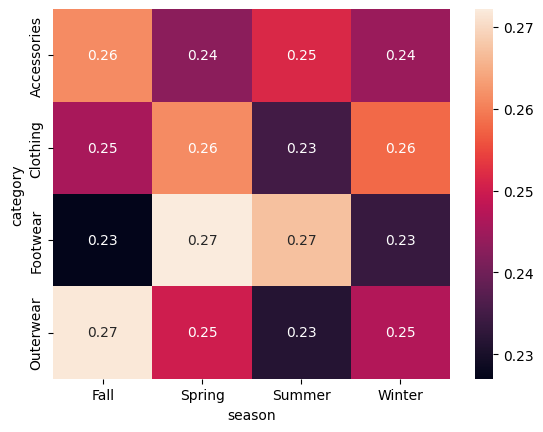

In [78]:
sns.heatmap(
    pd.crosstab(df["category"], df["season"], normalize="index"),
    annot=True,
    fmt=".2f"
)


- The heatmap shows a largely balanced distribution of purchases across seasons for all product categories.
- No category demonstrates strong seasonal dominance, as values remain close across all seasons.
- Footwear shows slightly higher concentration in Spring and Summer, indicating mild warm-season preference.
- Outerwear displays marginally higher activity in Fall, aligning with expected seasonal usage patterns.
- Clothing and Accessories maintain relatively stable demand throughout the year.

Overall, category–season interactions are weak to moderate, suggesting that customer demand remains consistent year-round, with only minor seasonal influence on specific product types.

---

# **Customer Behavior Patterns** 

---

Analysis indicates that customer behavior is largely stable across demographic and seasonal dimensions, with limited influence from age or time of year on transaction value.

Spending patterns remain relatively consistent across product categories, suggesting that customers differ more in purchase frequency and engagement style rather than average order value.

Subscription status emerges as a meaningful behavioral differentiator, with subscribed customers demonstrating higher repeat purchasing behavior and stronger responsiveness to promotional offers.

Overall, customer actions appear to be driven more by engagement mechanisms (subscriptions, promotions, product preferences) than by demographic factors alone.

---

# **Key Observations & Hypotheses** 

---

Key Observations

- Purchase amount shows minimal correlation with age and prior purchase count.
- Category and season exhibit limited impact on transaction value.
- Discounts are more frequently utilized by subscribed customers.
- Subscribed customers display higher historical purchase activity, indicating stronger retention.

Hypothesis 1: Customers are segmented more by engagement than demographics
-  Age → no correlation
-  Purchase behavior differs by subscription
-  Season/category weak

➡ Supported by data.

Hypothesis 2: Subscriptions increase repeat purchases, not transaction value
- Subscribers have more previous purchases
- Purchase amount remains similar
- Strongly supported.

Hypothesis 3: Discounts drive activation, not higher spend
- Discounted orders have slightly lower average spend
- Strong discount–subscription linkage
- Supported.

Hypothesis 4: Revenue growth comes from frequency, not AOV
- AOV stable everywhere
- Engagement varies
- Very strong conclusion.

Final Behavioral Summary

Customer behavior reflects a stable spending structure with heterogeneous engagement patterns, where loyalty mechanisms and promotional responsiveness play a larger role in driving long-term value than age, seasonality, or single-transaction characteristics.

---

# **Next Steps** 

---

Subsequent steps will focus on:

- Feature Engineering
- Post Feature Validation
- SQL Business Queries
- Dashboarding in PowerBI
